In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [3]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [4]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
inertia = []
k_range = range(1,11)

In [7]:
for  k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=43)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[1000.0,
 297.8954141051723,
 11.57548472310498,
 10.243817055323913,
 8.417187367576526,
 6.926618426993421,
 6.270151567129565,
 5.723131726606977,
 5.078146623447688,
 4.701760370114629]

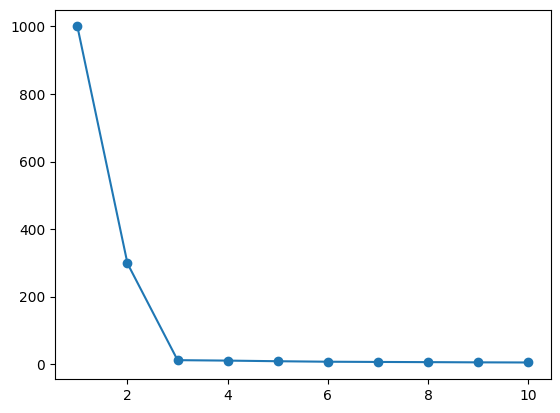

In [9]:
plt.plot(k_range, inertia, marker='o')

In [10]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [11]:
cluster_label = kmeans_final.fit_predict(X_scaled)

In [12]:
df['cluster'] = cluster_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

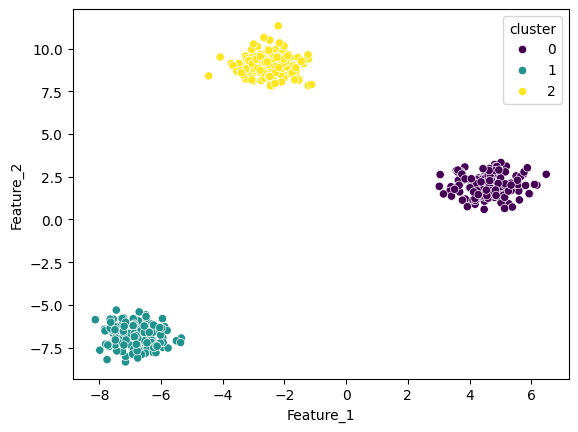

In [13]:
sns.scatterplot(x = df['Feature_1'],
                y = df['Feature_2'],
                hue = df['cluster'],
                palette='viridis')